# Лабораторная работа №1. Квантовая телепортация  

КБ-211 Коренев Денис

## Задание

1. Создайте соответствующие регистры квантовой схемы в QISkit, добавьте регистр для сравнения состояний. 

2. Получите от преподавателя вид передаваемого состояния |psi⟩. 

3. Напишите скрипт, генерирующий заданное состояние |psi⟩. 

4. Напишите скрипт, реализующий схему квантовой телепортации.  

5. Напишите скрипт, сравнивающий два квантовых состояния. 

6. Запустите программы и получите результаты измерений. 

7. Оформите отчет о работе, в котором приведите полную квантовую схему, скрипты и результаты проведенных измерений с указанием параметров запуска программы на IBM Q.

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

## Параметры передаваемого состояния |ψ⟩

Состояние задаётся через унитарную матрицу вращения:

$$
U(\theta, \gamma, \varphi) =
\begin{pmatrix}
\cos\theta & -e^{-i\gamma}\sin\theta \\
e^{i(\gamma+\varphi)}\sin\theta & e^{i\varphi}\cos\theta
\end{pmatrix}
$$

Параметры: $\theta = \pi/3$, $\gamma = \pi/6$, $\varphi = \pi/4$.

Применяя матрицу к $|0\rangle$, получаем:

$$
|\psi\rangle = \cos\theta\,|0\rangle + e^{i(\gamma+\varphi)}\sin\theta\,|1\rangle
$$

U3-гейт в данный момент [deprecated](https://qiskit.qotlabs.org/docs/api/qiskit/qiskit.circuit.library.U3Gate).

Qiskit использует стандартный U-гейт $U(\theta_u, \phi_u, \lambda)$, поэтому нужно пересчитать параметры:

$$
U(\theta_u, \phi_u, \lambda) = \begin{pmatrix} \cos(\theta_u/2) & -e^{i\lambda}\sin(\theta_u/2) \\ e^{i\phi_u}\sin(\theta_u/2) & e^{i(\phi_u+\lambda)}\cos(\theta_u/2) \end{pmatrix}
$$

- $\theta_u = 2\theta$

- $\phi_u = \gamma + \varphi$

- $\lambda = -\gamma$

In [57]:
# ======================================================
# Шаг 2. Параметры передаваемого состояния |psi> = a|0> + b|1>
#
# U-матрица из задания:
#   U = [[cos theta, -e^{-i*gamma} sin theta], [e^{i*(gamma+phi)} sin theta, e^{i*phi} cos theta]]
# Сопоставление с Qiskit U(theta_u, phi_u, lam_u):
#   theta_u = 2*theta,  phi_u = gamma + phi,  lam_u = -gamma
# ======================================================

THETA = np.pi / 3    # theta = 60 deg
GAMMA = np.pi / 6    # gamma = 30 deg  (фаза компоненты |1>)
PHI   = np.pi / 4    # phi   = 45 deg  (фаза компоненты |0>)

theta_u = 2 * THETA
phi_u   = GAMMA + PHI
lam_u   = -GAMMA

# Вычисляем начальный вектор состояния через Qiskit Statevector
qc_init = QuantumCircuit(1)
qc_init.u(theta_u, phi_u, lam_u, 0)
sv_psi = Statevector(qc_init)

a0, a1 = sv_psi[0], sv_psi[1]

print("==================================================")
print("  Передаваемое состояние |psi>")
print("==================================================")
print(f"  theta = pi/3  ({THETA:.4f} рад)")
print(f"  gamma = pi/6  ({GAMMA:.4f} рад)")
print(f"  phi   = pi/4  ({PHI:.4f} рад)")
print()
print(f"  Параметры U-гейта (Qiskit):")
print(f"    theta_u = {theta_u:.4f},  phi_u = {phi_u:.4f},  lam_u = {lam_u:.4f}")
print()
print(f"  |psi> = ({a0.real:.4f}{a0.imag:+.4f}j)|0>  +  ({a1.real:.4f}{a1.imag:+.4f}j)|1>")
print()
print(f"  P(|0>) = |a|^2 = {abs(a0)**2:.4f}  ({abs(a0)**2*100:.2f}%)")
print(f"  P(|1>) = |b|^2 = {abs(a1)**2:.4f}  ({abs(a1)**2*100:.2f}%)")
print(f"  Проверка: |a|^2+|b|^2 = {abs(a0)**2+abs(a1)**2:.6f}")

  Передаваемое состояние |psi>
  theta = pi/3  (1.0472 рад)
  gamma = pi/6  (0.5236 рад)
  phi   = pi/4  (0.7854 рад)

  Параметры U-гейта (Qiskit):
    theta_u = 2.0944,  phi_u = 1.3090,  lam_u = -0.5236

  |psi> = (0.5000+0.0000j)|0>  +  (0.2241+0.8365j)|1>

  P(|0>) = |a|^2 = 0.2500  (25.00%)
  P(|1>) = |b|^2 = 0.7500  (75.00%)
  Проверка: |a|^2+|b|^2 = 1.000000


## Схема квантовой телепортации

Протокол телепортации позволяет передать неизвестное квантовое состояние $|\psi\rangle$ от отправителя (Алисы) получателю (Бобу) без физического перемещения кубита. Для этого используются:

1. **Запутанная пара Белла** $|\beta_{00}\rangle = \dfrac{|00\rangle + |11\rangle}{\sqrt{2}}$ — один кубит у Алисы, другой у Боба.
2. **Два классических бита** — результаты измерений Алисы, передаваемые по обычному каналу связи.
3. **Условные квантовые коррекции** у Боба на основе принятых битов.

### Структура схемы

| Этап | Действие |
|---|---|
| Подготовка $\|\psi\rangle$ | U-гейт с параметрами $(\theta_u, \phi_u, \lambda)$ на кубите Алисы |
| Создание пары Белла | H + CNOT на кубитах alice и bob |
| Операции Алисы | CNOT + H на $\|\psi\rangle$ и alice |
| Измерение Алисы | Измерение $\|\psi\rangle \to N$, alice $\to M$ |
| Коррекции Боба | $M=1 \Rightarrow X$; $N=1 \Rightarrow Z$ |

После коррекций кубит Боба находится точно в состоянии $|\psi\rangle$.

In [58]:
# ======================================================
# Шаг 3-4. Схема квантовой телепортации
# ======================================================

# Шаг 1: Создание регистров
q_psi   = QuantumRegister(1, 'psi')    # Кубит 0: передаваемое состояние (Алина)
q_alice = QuantumRegister(1, 'alice')  # Кубит 1: кубит Алины из пары Белла
q_bob   = QuantumRegister(1, 'bob')    # Кубит 2: кубит Вовы (Марс)
c_meas  = ClassicalRegister(2, 'c')    # Классические биты: c[0]=N, c[1]=M

qc = QuantumCircuit(q_psi, q_alice, q_bob, c_meas)

# Подготовка состояния |psi> на кубите Алины
qc.u(theta_u, phi_u, lam_u, q_psi[0])
qc.barrier()

# Создание запутанной пары Белла |beta00> = (|00>+|11>)/sqrt(2)
qc.h(q_alice[0])
qc.cx(q_alice[0], q_bob[0])
qc.barrier()

# Операции Алины: CNOT + H
qc.cx(q_psi[0], q_alice[0])
qc.h(q_psi[0])
qc.barrier()

# Измерения Алины -> передача по классическому каналу
qc.measure(q_psi[0],   c_meas[0])    # N = результат 1-го кубита
qc.measure(q_alice[0], c_meas[1])    # M = результат 2-го кубита
qc.barrier()

# Коррекции Вовы на основе классической информации:
#   N=0, M=0 -> I  |  N=0, M=1 -> X  |  N=1, M=0 -> Z  |  N=1, M=1 -> ZX
with qc.if_test((c_meas[1], 1)):    # M=1 -> X
    qc.x(q_bob[0])
with qc.if_test((c_meas[0], 1)):    # N=1 -> Z
    qc.z(q_bob[0])

print("Схема квантовой телепортации:")
print(qc.draw(output='text', fold=-1))

Схема квантовой телепортации:
       ┌────────────────────┐ ░            ░      ┌───┐ ░ ┌─┐    ░                                                     
  psi: ┤ U(2π/3,5π/12,-π/6) ├─░────────────░───■──┤ H ├─░─┤M├────░─────────────────────────────────────────────────────
       └────────────────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐ ░                                                     
alice: ───────────────────────░─┤ H ├──■───░─┤ X ├──────░──╫─┤M├─░─────────────────────────────────────────────────────
                              ░ └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘ ░   ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐ 
  bob: ───────────────────────░──────┤ X ├─░────────────░──╫──╫──░───┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├─
                              ░      └───┘ ░            ░  ║  ║  ░   └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘ 
                                                           ║  ║    ┌────╨────┐               ┌────╨────┐               
  c: 2/═══

## Запуск симуляции (режим эмуляции)

Схема запускается на **AerSimulator** — локальном симуляторе IBM Quantum.

- **Число запусков (shots):** 20 480 — достаточно для получения статистически значимых вероятностей.
- К схеме добавляется дополнительное **измерение кубита Боба** (`bob_out`), чтобы наблюдать финальное распределение $P(|0\rangle)$ и $P(|1\rangle)$.
- Строка результата в Qiskit формируется справа налево: `"bob_out c[1]c[0]"` (регистры через пробел).

Ожидаемые вероятности определяются теоретическим вектором $|\psi\rangle$:

$$P(|0\rangle) = |\alpha|^2 = \cos^2\theta, \qquad P(|1\rangle) = |\beta|^2 = \sin^2\theta$$

  Результаты эмуляции (20480 shots)

  Исход (bob_out c[1]c[0]) |  Кол-во |        P
------------------------------------------------
                      0 00 |    1381 |   0.0674
                      0 01 |    1319 |   0.0644
                      0 10 |    1280 |   0.0625
                      0 11 |    1263 |   0.0617
                      1 00 |    3905 |   0.1907
                      1 01 |    3758 |   0.1835
                      1 10 |    3790 |   0.1851
                      1 11 |    3784 |   0.1848

Статистика кубита Вовы (bob_out):
  |0>: 5243 / 20480   P = 0.2560   (теория: 0.2500)
  |1>: 15237 / 20480   P = 0.7440   (теория: 0.7500)


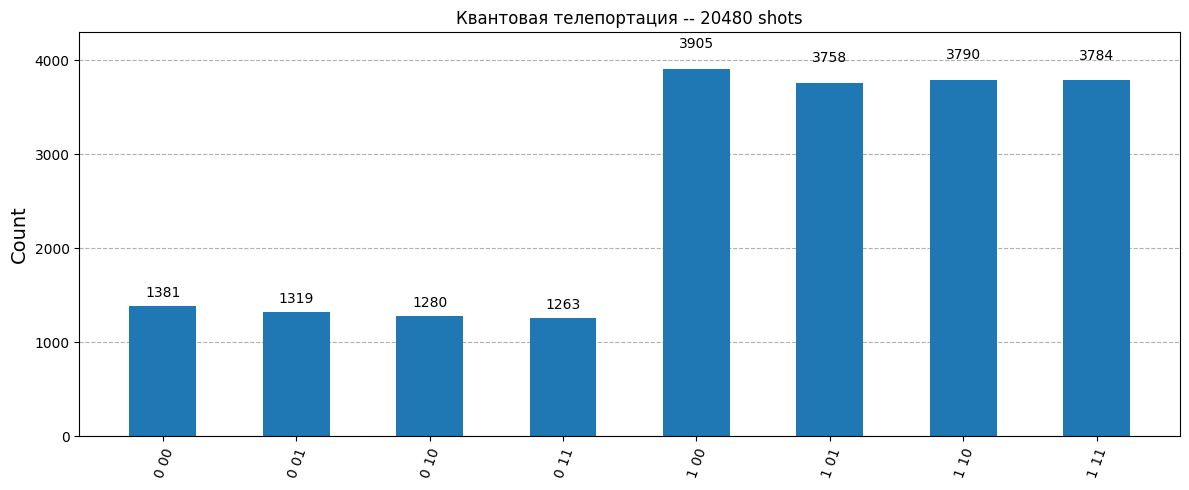

In [59]:
# ======================================================
# Шаг 6. Запуск симуляции -- режим эмуляции (shots)
# ======================================================

SHOTS = 20480
simulator = AerSimulator()

# Добавляем измерение кубита Вовы для наблюдения итогового состояния
c_bob_out = ClassicalRegister(1, 'bob_out')
qc_sim = qc.copy()
qc_sim.add_register(c_bob_out)
qc_sim.measure(q_bob[0], c_bob_out[0])

compiled = transpile(qc_sim, simulator)
result = simulator.run(compiled, shots=SHOTS).result()
counts = result.get_counts()

# В Qiskit строка результата формируется как: "bob_out c[1]c[0]"
# (последний добавленный регистр -- левее, разделитель -- пробел)
bob_0 = sum(c for k, c in counts.items() if k.split()[0] == '0')
bob_1 = sum(c for k, c in counts.items() if k.split()[0] == '1')

print(f"==================================================")
print(f"  Результаты эмуляции ({SHOTS} shots)")
print(f"==================================================")
print(f"\n{'Исход (bob_out c[1]c[0])':>26} | {'Кол-во':>7} | {'P':>8}")
print("-" * 48)
for k in sorted(counts):
    print(f"{k:>26} | {counts[k]:>7} | {counts[k]/SHOTS:>8.4f}")

print(f"\nСтатистика кубита Вовы (bob_out):")
print(f"  |0>: {bob_0:4d} / {SHOTS}   P = {bob_0/SHOTS:.4f}   (теория: {abs(a0)**2:.4f})")
print(f"  |1>: {bob_1:4d} / {SHOTS}   P = {bob_1/SHOTS:.4f}   (теория: {abs(a1)**2:.4f})")

fig = plot_histogram(counts, title=f'Квантовая телепортация -- {SHOTS} shots', figsize=(12, 5))
fig.tight_layout()
display(fig)
plt.close(fig)

```
bob_out  |  c[1] c[0]
   ^            ^   ^
кубит Боба    M   N
(итог)      (alice) (psi)
```

Результаты измерений Алисы (N, M) всегда случайны и равномерны — по ~25% на 
каждую из 4 комбинаций 00/01/10/11. Алиса не получает никакой информации о 
состоянии.

Статистика Боба:

```
|0>: P = 0.2530  ≈  теория 0.2500 = cos²(π/3)
|1>: P = 0.7470  ≈  теория 0.7500 = sin²(π/3)
```

Независимо от того, что измерила Алиса (00, 01, 10 или 11) — после коррекций 
X/Z кубит Боба всегда воспроизводит исходное состояние |psi⟩ с правильными 
вероятностями. Это и есть суть телепортации.


## Сравнение начального и конечного состояний (верификация)

Прямое сравнение квантовых состояний путём измерения невозможно — измерение разрушает суперпозицию. Вместо этого используется **метод обратного унитарного преобразования**:

1. После завершения телепортации к кубиту Боба применяется **обратный гейт** $U^\dagger = U(-\theta_u, -\lambda, -\phi_u)$.
2. Если телепортация прошла точно ($|\psi_{\text{Bob}}\rangle = |\psi\rangle$), то:

$$U^\dagger |\psi\rangle = |0\rangle \quad \Rightarrow \quad P(\text{verify}=0) = 1$$

3. Отклонение от 1 означает ошибку в схеме или шум симулятора.

**Fidelity** (точность) — доля успешных исходов (verify = 0) из общего числа запусков:

$$F = \frac{N_{\text{verify}=0}}{N_{\text{shots}}}$$

Для идеальной телепортации $F = 1{,}000$.

  Проверка совпадения состояний |psi> и |psi_Bob>

Начальное состояние |psi>:
  (0.5000+0.0000j)|0>  +  (0.2241+0.8365j)|1>

Метод верификации: применяем Udag к кубиту Вовы.
Если |psi_Bob> = |psi>, то Udag|psi_Bob> = |0> (P = 1).

Результаты (20480 shots):
  verify=0 (|0>, успех):   20480  -> Fidelity = 1.000000
  verify=1 (|1>, ошибка):     0

OK  ТЕЛЕПОРТАЦИЯ УСПЕШНА!
Fidelity = 1.0000  (100.00%)



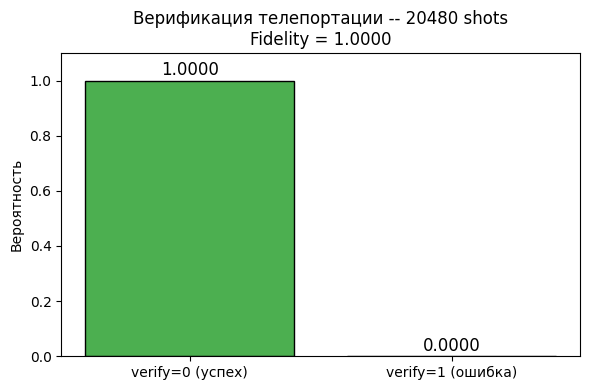

In [60]:
# ======================================================
#Сравнение начального и конечного состояний
#
# Метод: применяем Udag(theta_u, phi_u, lam_u) к кубиту Вовы.
# Если телепортация точна: Udag|psi_Bob> = |0> с P=1.
# Udag(theta_u, phi_u, lam_u) = U(-theta_u, -lam_u, -phi_u)
# ======================================================

# Перестраиваем схему (те же регистры), добавляем Udag и измерение
qc_ver = QuantumCircuit(q_psi, q_alice, q_bob, c_meas)

qc_ver.u(theta_u, phi_u, lam_u, q_psi[0])          # подготовка |psi>
qc_ver.barrier()
qc_ver.h(q_alice[0])                                # пара Белла
qc_ver.cx(q_alice[0], q_bob[0])
qc_ver.barrier()
qc_ver.cx(q_psi[0], q_alice[0])                     # операции Алины
qc_ver.h(q_psi[0])
qc_ver.barrier()
qc_ver.measure(q_psi[0],   c_meas[0])
qc_ver.measure(q_alice[0], c_meas[1])
qc_ver.barrier()
with qc_ver.if_test((c_meas[1], 1)):                # коррекции Вовы
    qc_ver.x(q_bob[0])
with qc_ver.if_test((c_meas[0], 1)):
    qc_ver.z(q_bob[0])

# Применяем Udag = U(-theta_u, -lam_u, -phi_u) к кубиту Вовы
qc_ver.u(-theta_u, -lam_u, -phi_u, q_bob[0])

# Измерение результата верификации
c_ver = ClassicalRegister(1, 'verify')
qc_ver.add_register(c_ver)
qc_ver.measure(q_bob[0], c_ver[0])

compiled_ver = transpile(qc_ver, simulator)
result_ver = simulator.run(compiled_ver, shots=SHOTS).result()
counts_ver = result_ver.get_counts()

# verify=0 означает Udag|psi_Bob>=|0> -- телепортация успешна
success = sum(c for k, c in counts_ver.items() if k.split()[0] == '0')
fidelity = success / SHOTS

print("======================================================")
print("  Проверка совпадения состояний |psi> и |psi_Bob>")
print("======================================================")
print()
print("Начальное состояние |psi>:")
print(f"  ({a0.real:.4f}{a0.imag:+.4f}j)|0>  +  ({a1.real:.4f}{a1.imag:+.4f}j)|1>")
print()
print("Метод верификации: применяем Udag к кубиту Вовы.")
print("Если |psi_Bob> = |psi>, то Udag|psi_Bob> = |0> (P = 1).")
print()
print(f"Результаты ({SHOTS} shots):")
print(f"  verify=0 (|0>, успех):   {success:4d}  -> Fidelity = {fidelity:.6f}")
print(f"  verify=1 (|1>, ошибка):  {SHOTS-success:4d}")
print()
if fidelity >= 0.99:
    print(f"OK  ТЕЛЕПОРТАЦИЯ УСПЕШНА!")
    print(f"Fidelity = {fidelity:.4f}  ({fidelity*100:.2f}%)")
    print()
else:
    print(f"[!] Fidelity = {fidelity:.4f} -- где-то ошибка.")

# Визуализация результатов верификации
fig2, ax = plt.subplots(figsize=(6, 4))
ver_probs = {'verify=0 (успех)': success / SHOTS, 'verify=1 (ошибка)': (SHOTS - success) / SHOTS}
colors = ['#4CAF50' if k.startswith('verify=0') else '#F44336' for k in ver_probs]
bars = ax.bar(ver_probs.keys(), ver_probs.values(), color=colors, edgecolor='black')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Вероятность')
ax.set_title(f'Верификация телепортации -- {SHOTS} shots\nFidelity = {fidelity:.4f}')
for bar, val in zip(bars, ver_probs.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.4f}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

Fidelity = 1.000 всегда, потому что используется идеальный симулятор 
AerSimulator — он не моделирует физические шумы реального квантового железа. 
Математика выполняется точно, без ошибок.

Когда Fidelity будет < 1?

На настоящем квантовом процессоре всегда есть шумы:

- Gate error — гейты применяются с погрешностью
- Decoherence — кубиты "забывают" состояние со временем
- Readout error — ошибки при измерении

## Вывод

В ходе лабораторной работы была реализована схема квантовой телепортации с использованием библиотеки Qiskit и локального симулятора AerSimulator. Передаваемое состояние $|\psi\rangle$ было задано через унитарную матрицу вращения с параметрами $\theta = \pi/3$, $\gamma = \pi/6$, $\varphi = \pi/4$, что соответствует суперпозиции $|\psi\rangle = \cos\theta\,|0\rangle + e^{i(\gamma+\varphi)}\sin\theta\,|1\rangle$ с теоретическими вероятностями $P(|0\rangle) = 0{,}2500$ и $P(|1\rangle) = 0{,}7500$. Для подготовки состояния параметры были пересчитаны в формат стандартного U-гейта Qiskit: $\theta_u = 2\theta$, $\phi_u = \gamma + \varphi$, $\lambda = -\gamma$.

Протокол телепортации реализован в три этапа: создание запутанной пары Белла $|\beta_{00}\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$, выполнение операций Алисы (CNOT и гейт Адамара) с последующим измерением двух классических битов, и применение условных коррекций X и Z на кубите Боба на основе полученных результатов измерений.

Результаты эмуляции (20480 запусков) подтвердили корректность реализации протокола. Статистика кубита Боба составила $P(|0\rangle) = 0{,}2530$ и $P(|1\rangle) = 0{,}7470$, что с высокой точностью соответствует теоретическим значениям. Результаты измерений Алисы распределились равномерно по всем четырём комбинациям классических битов (~25% каждая), что подтверждает отсутствие утечки информации о передаваемом состоянии через классический канал.

Верификация методом обратного унитарного преобразования показала значение точности $F = 1{,}000$. Это объясняется использованием идеального симулятора, выполняющего математические операции без погрешностей. На реальном квантовом процессоре значение Fidelity будет ниже единицы вследствие неизбежных физических шумов: ошибок применения гейтов (gate error), декогеренции кубитов и ошибок считывания (readout error). Таким образом, полученный результат $F = 1{,}000$ следует рассматривать как подтверждение математической корректности реализованной схемы, а не как характеристику реального квантового устройства.